![](https://miro.medium.com/v2/resize:fit:512/1*IMGOKBIN8qkOBt5CH55NSw.png)

# Section 2: Architectures in PyTorch

## What we are going to cover


## 2. Loading and Preprocessing Image Datasets with PyTorch

In this tutorial, we will cover the essential steps to load and preprocess image datasets using PyTorch. We'll use a real-world business case related dataset to make it practical and relevant. The dataset we'll use is the "Intel Image Classification" dataset, which contains images of various natural scenes categorized into six classes.

Dataset link: (https://www.kaggle.com/datasets/puneet6060/intel-image-classification/data)


### 1. What is Computer Vision?

Computer vision is a field of artificial intelligence that enables computers to interpret and make decisions based on visual data.

### Importing libraries


In [ ]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

### 3. Loading the Dataset
The "Intel Image Classification" dataset can be downloaded from Kaggle. We will use the torchvision.datasets.ImageFolder to load the dataset.

First, download the dataset from Kaggle and unzip it to your working directory.

In [ ]:
!unzip data.zip

Archive:  ./data.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of ./data or
        ./data.zip, and cannot find ./data.ZIP, period.


In [ ]:
data_dir_train = "seg_train"
data_dir_test = "seg_test"

### 4. Preprocessing the Dataset
Preprocessing is an essential step in preparing the data for training. Common preprocessing steps include resizing, normalization, and data augmentation.

Define the transformations:

In [ ]:
# Define the transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images to 128x128 pixels
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize the images
])

### 5. Creating Data Loaders
Data loaders in PyTorch help in efficiently loading data during training. We will create a data loader for our training dataset.

In [ ]:
# Load the dataset with the defined transformations
dataset = datasets.ImageFolder(root=data_dir_train, transform=transform)
dataset_test = datasets.ImageFolder(root=data_dir_test, transform=transform)

In [ ]:
# Split the dataset into training and validation sets (80-20 split)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

In [ ]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### 6. Visualizing the Data
Visualizing the data helps in understanding the dataset and verifying that the preprocessing steps are correctly applied.

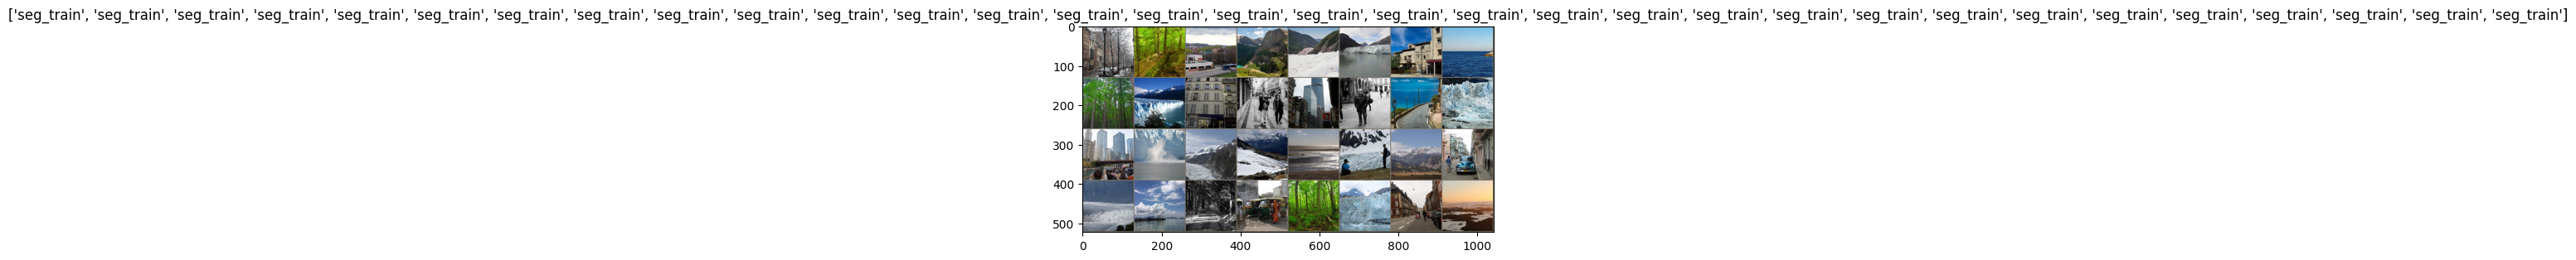

In [ ]:
# Function to visualize a batch of images
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of training data
inputs, classes = next(iter(train_loader))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[dataset.classes[x] for x in classes])

## 3. Understanding and Implementing a Basic CNN

In this tutorial, we will explore Convolutional Neural Networks (CNNs), a class of deep neural networks commonly used for analyzing visual data. We will understand the basic architecture of CNNs and implement a simple CNN model using PyTorch.

### Introduction to CNNs

Convolutional Neural Networks (CNNs) are specialized deep neural networks designed to process structured grid data, such as images. They have shown remarkable performance in tasks like image classification, object detection, and more.

### Understanding CNN Architecture

A typical CNN architecture consists of the following layers:
- **Convolutional Layers:** Apply convolution operations to the input data to extract features.
- **Activation Functions:** Introduce non-linearity into the model.
- **Pooling Layers:** Reduce the spatial dimensions of the data.
- **Fully Connected Layers:** Perform classification based on the extracted features.

### Wait wait, but can we use FCN for images as well? And if not why not?

![](https://i.ibb.co/JKqCYmG/Screenshot-2024-06-22-at-22-46-03.png)


### General architecture of a CNN model


![](https://i.ibb.co/5MckwHJ/Screenshot-2024-06-22-at-22-46-10.png)

### Explanation of CNN operations:


![](https://i.ibb.co/Bz0HNYh/Screenshot-2024-06-22-at-22-46-15.png)

![](https://i.ibb.co/tqp2H8M/Screenshot-2024-06-22-at-22-46-23.png)

![](https://i.ibb.co/NVrRn4z/Screenshot-2024-06-22-at-22-46-29.png)

![](https://i.ibb.co/Mk6qzNZ/Screenshot-2024-06-22-at-22-46-36.png)

![](https://miro.medium.com/v2/resize:fit:1400/0*fnHYnmwI_wmfwGAp.gif)







In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
class BasicCNN(nn.Module):
    def __init__(self):
        super(BasicCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(16 * 128 * 128, 6)  # Adjust based on input size and output classes

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = self.fc1(x)
        return x


###  Training and Evaluating the CNN

To train our model, we need to define a loss function and an optimizer. We'll use Cross-Entropy Loss and the Adam optimizer.


In [ ]:
# Define the model, loss function, and optimizer
model = BasicCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Training the model
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')

### Evaluation

Finally, let's evaluate our model on the validation set:

In [ ]:
# Evaluate the model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Validation Accuracy: {accuracy * 100:.2f}%')


## 4. Layers in CNNs and Implementing Advanced Features

In this tutorial, we will dive deeper into the architecture of Convolutional Neural Networks (CNNs). We will understand the different layers involved in a CNN, such as pooling and fully connected layers, and implement a more advanced CNN model.


### What are pooling layers?

Pooling layers are used in CNNs to decrease general size of an input tensor (or an image). They are acomplising this by simply looking at different image/tensor regions and checking what is the highest value of pixel (ie which color is brighest). We only capture and persever that number and the rest is discarded.

![](https://i.ibb.co/93kVBk0/Screenshot-2024-06-22-at-22-46-59.png)

![](https://i.ibb.co/1JwVn22/Screenshot-2024-06-22-at-22-47-04.png)

![](https://i.ibb.co/QJf3gGx/Screenshot-2024-06-22-at-22-47-09.png)




In [ ]:
class BasicCNNV2(nn.Module):
    def __init__(self):
        super(BasicCNNV2, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 16 * 16, 512)  # Adjust based on input size and output classes
        self.fc2 = nn.Linear(512, 6)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


###  Training and Evaluating the Improved CNN

Define the loss function and optimizer:

In [ ]:
# Define the model, loss function, and optimizer
model = BasicCNNV2()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Training the model
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')


### Evaluation

Evaluate the model on the validation set:


In [ ]:
# Evaluate the model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Validation Accuracy: {accuracy * 100:.2f}%')


## 5. Data Augmentation and Regularization Techniques

In this tutorial, we will explore advanced techniques to improve the performance of Convolutional Neural Networks (CNNs). These techniques include data augmentation for images and regularization techniques.

### What is Data Augmentation for Images?

Data augmentation is a technique used to artificially expand the size of a training dataset by creating modified versions of images. Common augmentation techniques include:
- Rotation
- Flipping
- Scaling
- Cropping
- Color jitter

Data augmentation helps in improving the robustness of the model by exposing it to a variety of image transformations.
![](https://albumentations.ai/docs/images/introduction/image_augmentation/augmentation.jpg)
### What are Regularization Techniques?

Regularization techniques help in reducing overfitting and improving the generalization of the model. Common regularization techniques include:
- **Dropout:** Randomly sets a fraction of input units to 0 at each update during training time, which helps in preventing overfitting.
- **L2 Regularization:** Adds a penalty equal to the sum of the squared weights to the loss function, which helps in keeping the model weights small.



In [ ]:
# Define the transformations with data augmentation
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize(128),
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Load the dataset with the transformations
train_dataset = datasets.ImageFolder(root='Intel_Image_Classification/seg_train/seg_train', transform=transform_train)
val_dataset = datasets.ImageFolder(root='Intel_Image_Classification/seg_train/seg_train', transform=transform_val)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### Defining upgraded model with all changes

In [ ]:
class BasicCNNV3(nn.Module):
    def __init__(self):
        super(BasicCNNV3, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 16 * 16, 512)  # Adjust based on input size and output classes
        self.fc2 = nn.Linear(512, 6)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

### Training and Evaluating the Enhanced CNN

Define the loss function and optimizer with L2 regularization:


In [ ]:
# Define the model, loss function, and optimizer
model = BasicCNNV3()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # L2 regularization

In [ ]:
# Training the model
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')


### Evaluate model

In [ ]:
# Evaluate the model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Validation Accuracy: {accuracy * 100:.2f}%')


## 6. Introduction to Sequence Data

In this tutorial, we will explore sequence data, its unique characteristics, and how it differs from image data. We will also touch on basic processing techniques for sequence data using PyTorch.


### Introduction to Sequence Data

Sequence data is a type of data where the order of the elements is significant. Common examples include:
- Text data (sentences, paragraphs)
- Time series data (stock prices, weather data)
- Audio data (speech, music)

### Differences from Image Data

Sequence data differs from image data in several key ways:
- **Order Matters:** The sequence and timing of elements are crucial, unlike in images where spatial structure is important.
- **Variable Length:** Sequences can vary in length, while image data typically has fixed dimensions.
- **Temporal Dependencies:** In sequence data, past elements influence future elements, requiring models to account for these dependencies.



In [ ]:
# Install necessary libraries
!pip install torchtext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.5 MB/s eta 0:00:00



## Import the required libraries:


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
import numpy as np

### Load and Tokenize data

Define the fields for processing text and labels:

Dataset link: https://www.kaggle.com/datasets/crawford/20-newsgroups

In [ ]:
# Load IMDb dataset
categories = ['rec.autos', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.med']
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)

In [ ]:
# Vectorize the text data
vectorizer = CountVectorizer(max_features=10000, stop_words='english')
X_train_counts = vectorizer.fit_transform(newsgroups_train.data)
X_test_counts = vectorizer.transform(newsgroups_test.data)

In [ ]:
# Convert to dense tensors
X_train = torch.tensor(X_train_counts.toarray(), dtype=torch.float32)
X_test = torch.tensor(X_test_counts.toarray(), dtype=torch.float32)
y_train = torch.tensor(newsgroups_train.target, dtype=torch.long)
y_test = torch.tensor(newsgroups_test.target, dtype=torch.long)

In [ ]:

# Create custom dataset
class NewsGroupDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create data loaders
train_dataset = NewsGroupDataset(X_train, y_train)
test_dataset = NewsGroupDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Define Basic RNN

In [ ]:
class BasicRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(BasicRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), hidden_size).to(x.device)  # Initialize hidden state
        out, _ = self.rnn(x, h0)  # Pass through RNN layer
        out = self.fc(out[:, -1, :])  # Pass the last time step's output to the fully connected layer
        return out

In [ ]:
# Define the model, loss function, and optimizer
input_size = 10000  # Number of features
hidden_size = 256
output_size = len(categories)

model = BasicRNN(input_size, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [ ]:
# Training the model
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.view(inputs.size(0), 1, -1)  # Reshape to (batch_size, seq_len, input_size)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')

Epoch 1/5, Loss: 0.3762
Epoch 2/5, Loss: 0.0355
Epoch 3/5, Loss: 0.0117
Epoch 4/5, Loss: 0.0056
Epoch 5/5, Loss: 0.0034


In [ ]:
# Evaluate the model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.view(inputs.size(0), 1, -1)  # Reshape to (batch_size, seq_len, input_size)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Test Accuracy: {accuracy * 100:.2f}%')

Test Accuracy: 95.59%



### Implementing an LSTM Network
Let's continue from where we left off and implement a Long Short-Term Memory (LSTM) network to process the IMDb movie reviews dataset. We'll use the same preprocessing steps but replace the RNN with an LSTM network.

![](https://upload.wikimedia.org/wikipedia/commons/thumb/9/93/LSTM_Cell.svg/1200px-LSTM_Cell.svg.png)

Source: https://upload.wikimedia.org/wikipedia/commons/thumb/9/93/LSTM_Cell.svg/1200px-LSTM_Cell.svg.png

Define the LSTM architecture:

In [ ]:
class LSTMNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTMNetwork, self).__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [ ]:
# Define the model, loss function, and optimizer
input_size = 10000  # Number of features
hidden_size = 256
output_size = len(categories)

model = LSTMNetwork(input_size, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

### Training LSTM Network on the same dataset to compare results

In [ ]:
# Training the model
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.view(inputs.size(0), 1, -1)  # Reshape to (batch_size, seq_len, input_size)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')


Epoch 1/5, Loss: 0.5529
Epoch 2/5, Loss: 0.0499
Epoch 3/5, Loss: 0.0138
Epoch 4/5, Loss: 0.0058
Epoch 5/5, Loss: 0.0031


### Evaluate model

In [ ]:
# Evaluate the model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.view(inputs.size(0), 1, -1)  # Reshape to (batch_size, seq_len, input_size)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Test Accuracy: {accuracy * 100:.2f}%')

Test Accuracy: 95.59%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

import nltk
from nltk.tokenize import word_tokenize
from PIL import Image
import os
import json
import numpy as np
from collections import Counter
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
# !pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 14.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 14.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 22.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 16.6 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.31.0
    Uninstalling requests-2.31.0:
      Successfully uninstalled requests-2.31.0
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 14.0.2
    Uninstalling pyarrow-14.0.2:
      Successfully uninstalled pyarrow-14.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 2

## Loading the dataset

This time, we will use something called HuggingFace datasets to load our dataset.

The dataset name is: COCO
You can find more about it here: https://huggingface.co/datasets/RIW/small-coco?row=25

![](https://production-media.paperswithcode.com/datasets/0daad4f0-886b-44ed-9b96-80d99e037f16.png)

In [ ]:
from datasets import load_dataset

ds = load_dataset("RIW/small-coco")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/9890 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/9893 [00:00<?, ? examples/s]

### Building vocabulary from our captions

In [ ]:
# Create vocabulary from the captions
def build_vocab(captions, threshold):
    counter = Counter()
    for caption in captions:
        tokens = word_tokenize(caption.lower())
        counter.update(tokens)

    words = [word for word, cnt in counter.items() if cnt >= threshold]
    vocab = {word: idx for idx, word in enumerate(words, 4)}  # Reserve 0-3 for special tokens
    vocab['<pad>'] = 0
    vocab['<start>'] = 1
    vocab['<end>'] = 2
    vocab['<unk>'] = 3
    return vocab

captions = [item['caption'] for item in ds['train']]
vocab = build_vocab(captions, threshold=5)

In [ ]:
def encode_caption(caption, vocab):
    tokens = word_tokenize(caption.lower())
    caption_encoded = [vocab.get(token, vocab['<unk>']) for token in tokens]
    caption_encoded = [vocab['<start>']] + caption_encoded + [vocab['<end>']]
    return caption_encoded

def collate_fn(batch, pad_idx):
    images, captions = zip(*batch)
    images = torch.stack(images, dim=0)
    lengths = [len(cap) for cap in captions]
    captions = pad_sequence(captions, batch_first=True, padding_value=pad_idx)
    return images, captions, lengths


### Creating advanced torch dataset to capture both images and captions

In [ ]:
class CocoDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, vocab, transform=None):
        self.dataset = dataset
        self.vocab = vocab
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image = self.dataset[idx]['image']
        if image.mode != 'RGB':
            image = image.convert('RGB')

        if self.transform:
            image = self.transform(image)

        caption = self.dataset[idx]['caption']
        caption_encoded = encode_caption(caption, self.vocab)
        return image, torch.tensor(caption_encoded)

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = CocoDataset(ds['train'], vocab, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=lambda x: collate_fn(x, vocab['<pad>']))


### Let's creat our image encoder network!

![](https://raw.githubusercontent.com/yunjey/pytorch-tutorial/master/tutorials/03-advanced/image_captioning/png/model.png)
Img source: https://github.com/anunay999/image_captioning_vgg16

In [ ]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super(EncoderCNN, self).__init__()
        resnet = models.resnet50(pretrained=True)
        for param in resnet.parameters():
            param.requires_grad = False
        self.resnet = nn.Sequential(*list(resnet.children())[:-1])
        self.fc = nn.Linear(resnet.fc.in_features, embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, images):
        features = self.resnet(images)
        features = features.view(features.size(0), -1)
        features = self.fc(features)
        features = self.relu(features)
        features = self.dropout(features)
        return features

### From image to caption: Creating caption decoder network

In [ ]:
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, features, captions, lengths):

        embeddings = self.embed(captions)
        embeddings = torch.cat((features.unsqueeze(1), embeddings), 1)
        packed = pack_padded_sequence(embeddings, lengths, batch_first=True, enforce_sorted=False)
        hiddens, _ = self.lstm(packed)
        outputs, _ = pad_packed_sequence(hiddens, batch_first=True)
        outputs = self.fc(outputs)
        return outputs

    def sample(self, features, states=None, max_len=20):
        sampled_ids = []
        inputs = features.unsqueeze(1)
        for i in range(max_len):
            hiddens, states = self.lstm(inputs, states)
            outputs = self.fc(hiddens.squeeze(1))
            _, predicted = outputs.max(1)
            sampled_ids.append(predicted)
            inputs = self.embed(predicted)
            inputs = inputs.unsqueeze(1)
        sampled_ids = torch.stack(sampled_ids, 1)
        return sampled_ids


### Defining the full model (CNN + RNN)

In [ ]:
# Define hyperparameters
embed_size = 256
hidden_size = 512
vocab_size = len(vocab)

# Initialize the models, loss function, and optimizer
encoder = EncoderCNN(embed_size).to("cuda")
decoder = DecoderRNN(embed_size, hidden_size, vocab_size).to("cuda")
criterion = nn.CrossEntropyLoss(ignore_index=vocab['<pad>'])
params = list(decoder.parameters()) + list(encoder.fc.parameters())
optimizer = optim.Adam(params, lr=0.001)

In [ ]:
# Training loop
num_epochs = 10

for epoch in range(num_epochs):
    encoder.train()
    decoder.train()
    running_loss = 0.0

    for ims, caps, lengths in train_loader:
        ims, caps = ims.to("cuda"), caps.to("cuda")
        optimizer.zero_grad()

        features = encoder(ims)
        outputs = decoder(features, caps, lengths)

        outputs = outputs[:, 1:, :].contiguous().view(-1, vocab_size)
        caps = caps[:, 1:].contiguous().view(-1)
        loss = criterion(outputs, caps)

        loss.backward()
        optimizer.step()
        running_loss += loss.item() * ims.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10, Loss: 3.8317
Epoch 2/10, Loss: 3.1164
Epoch 3/10, Loss: 2.7813
Epoch 4/10, Loss: 2.5218
Epoch 5/10, Loss: 2.3069
Epoch 6/10, Loss: 2.1173
Epoch 7/10, Loss: 1.9396
Epoch 8/10, Loss: 1.7689
Epoch 9/10, Loss: 1.6145
Epoch 10/10, Loss: 1.4660


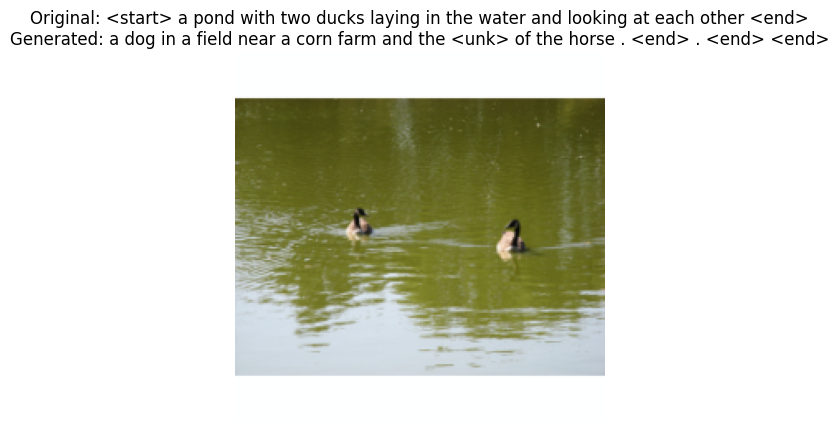

In [ ]:
import random
import matplotlib.pyplot as plt

# Helper function to decode the caption
def decode_caption(encoded_caption, vocab):
    idx_to_word = {idx: word for word, idx in vocab.items()}
    words = [idx_to_word.get(idx, '<unk>') for idx in encoded_caption]
    return ' '.join(words)

def evaluate_single_entry(encoder, decoder, dataset, vocab, index):
    encoder.eval()
    decoder.eval()

    # Get the specific entry
    image, caption_encoded = dataset[index]

    # Prepare the image
    image = image.unsqueeze(0).to("cuda")

    with torch.no_grad():
        features = encoder(image)
        sampled_ids = decoder.sample(features)
        sampled_ids = sampled_ids.cpu().numpy()

    # Decode the original and generated captions
    original_caption = decode_caption(caption_encoded.numpy(), vocab)
    generated_caption = decode_caption(sampled_ids[0], vocab)

    # Display the image
    img = image.squeeze(0).cpu().permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(f'Original: {original_caption}\nGenerated: {generated_caption}')
    plt.axis('off')
    plt.show()

# Example usage: Evaluate a specific entry
specific_index = random.randint(0, len(train_dataset) - 1)
evaluate_single_entry(encoder, decoder, train_dataset, vocab, specific_index)